In [1]:
from olmo.config import (
    CheckpointType,
    DDPGradSyncMode,
    DistributedStrategy,
    TrainConfig,
)
import torch
import mpl_scatter_density

from olmo.model import OLMo
from olmo.data import build_train_dataloader
import os
import torch.nn as nn
from olmo.model import LayerNorm, RMSLayerNorm
from collections import defaultdict
import matplotlib.pyplot as plt

In [14]:
full_path = "/n/holylfs06/LABS/sham_lab/Lab/ameterez/OLMo"
os.environ['CHECKPOINTS_PATH'] = '/n/netscratch/kempner_sham_lab/Everyone/ameterez/150m_1_chinchilla_1_repeat'

save_path = "/n/netscratch/kempner_sham_lab/Everyone/ameterez/layernorm_plots"
job_number = "28012014_10"
# job_number = "28012014_0"

job_path = f"{save_path}/{job_number}"
if not os.path.exists(job_path):
    os.mkdir(job_path)

exp_path = f"{os.environ['CHECKPOINTS_PATH']}/{job_number}"
import re

def get_unsharded_steps(names):
    """Return all 'step<N>-unsharded' entries sorted by N (numeric)."""
    pairs = []
    for s in names:
        m = re.fullmatch(r"step(\d+)-unsharded", s)
        if m:
            pairs.append((int(m.group(1)), s))
    return [s for _, s in sorted(pairs)]

steps_saved = get_unsharded_steps(os.listdir(f"{os.environ['CHECKPOINTS_PATH']}/26955159_4/"))

class LNDenominatorRecorder:
    """
    Attach forward hooks to all torch.nn.LayerNorm modules in `model`.
    On each forward, saves sqrt(Var(x) + eps) computed over the LayerNorm's normalized dims.
    """
    def __init__(self, model: nn.Module, layernorm_type: str):
        self.model = model

        self.step = 0
        self.cache: Dict[str, List[torch.Tensor]] = defaultdict(list)
        self._handles: List[torch.utils.hooks.RemovableHandle] = []
        self.layernorm_type = layernorm_type
        for name, module in self.model.named_modules():
            if isinstance(module, LayerNorm) or isinstance(module, RMSLayerNorm):
                h = module.register_forward_hook(self._make_hook_scatter_plot(name, module))
                # h = module.register_forward_hook(self._make_hook(name, module))
                self._handles.append(h)

    def _make_hook(self, name: str, module):
        eps = float(module.eps)
        norm_ndims = len(module.normalized_shape)
        safe_name = name.replace(".", "_")

        def hook(_mod, inputs, _output):
            x = inputs[0]
            x_f = x.detach().float()
            if self.layernorm_type == 'layernorm':
                dims = tuple(range(x_f.ndim - norm_ndims, x_f.ndim))
                mean = x_f.mean(dim=dims, keepdim=True)
                var  = (x_f - mean).pow(2).mean(dim=dims, keepdim=True) 
                denom = torch.rsqrt(var + eps)
            elif self.layernorm_type == 'rms':
                x32 = x.detach().to(torch.float32)
                variance = x32.pow(2).mean(dim=-1, keepdim=True)
                denom = torch.sqrt(variance + eps)  # shape [B, S, 1]
            else:
                print("No such norm!")
            to_save = denom.cpu().squeeze()
            self.cache[name] = to_save

        return hook
    def _make_hook_scatter_plot(self, name: str, module):
        safe_name = name.replace(".", "_")
        eps = float(module.eps)

        def hook(_mod, inputs_, outputs_):
            inputs = inputs_[0].detach()
            x32 = inputs.to(torch.float32)
            variance = x32.pow(2).mean(dim=-1, keepdim=True)
            denom = torch.sqrt(variance + eps)  # shape [B, S, 1]
            outputs = inputs / denom
            self.cache[name] = (inputs[:, :128, :].cpu().squeeze(), outputs[:, :128, :].cpu().squeeze())
        return hook

    def next_step(self):
        self.step += 1

    def close(self):
        for h in self._handles:
            h.remove()
        self._handles.clear()


# fix some batch of data 
batch = None

step100-unsharded


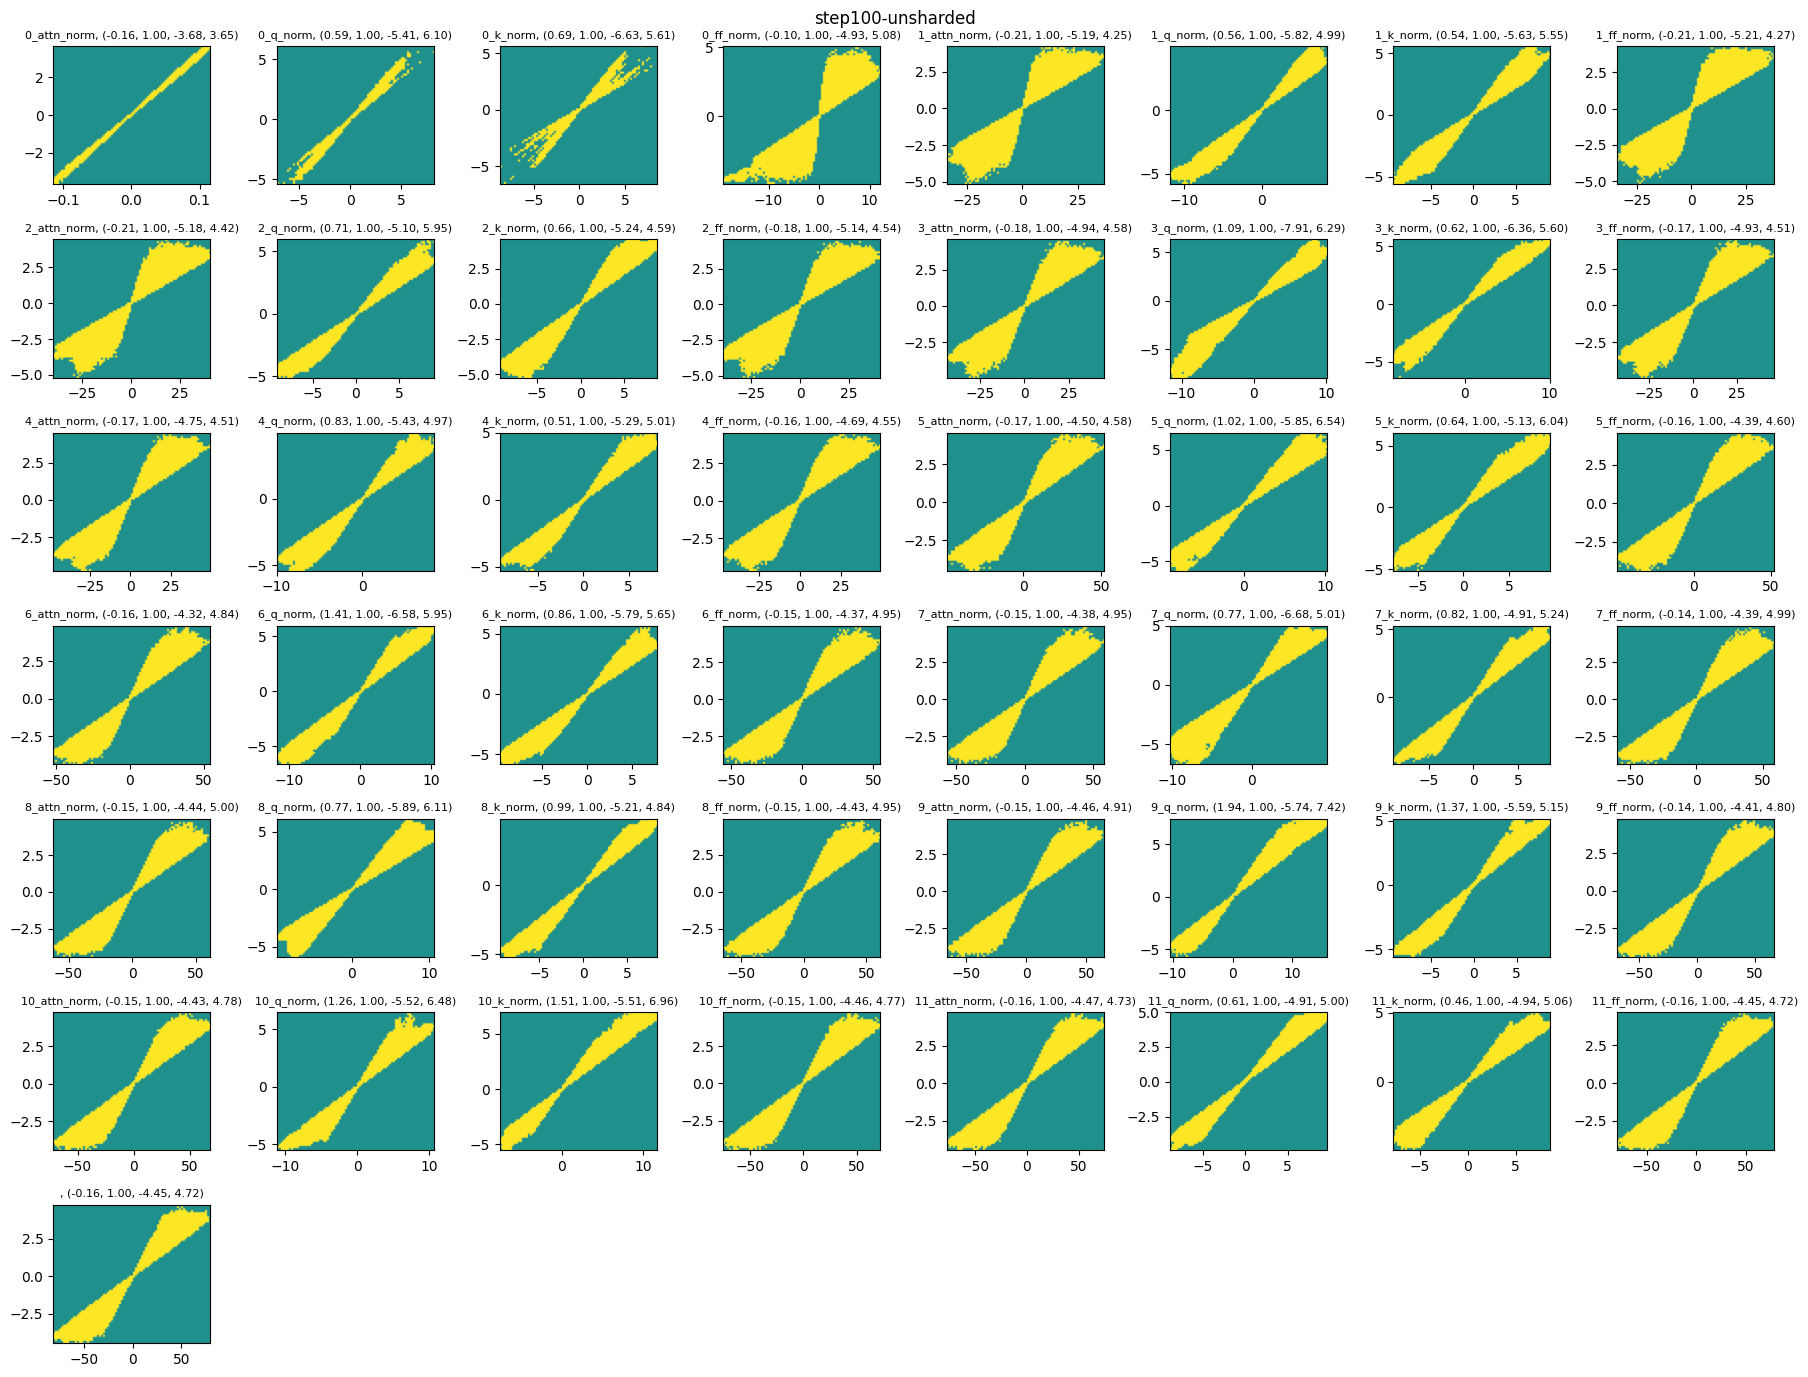

step1100-unsharded


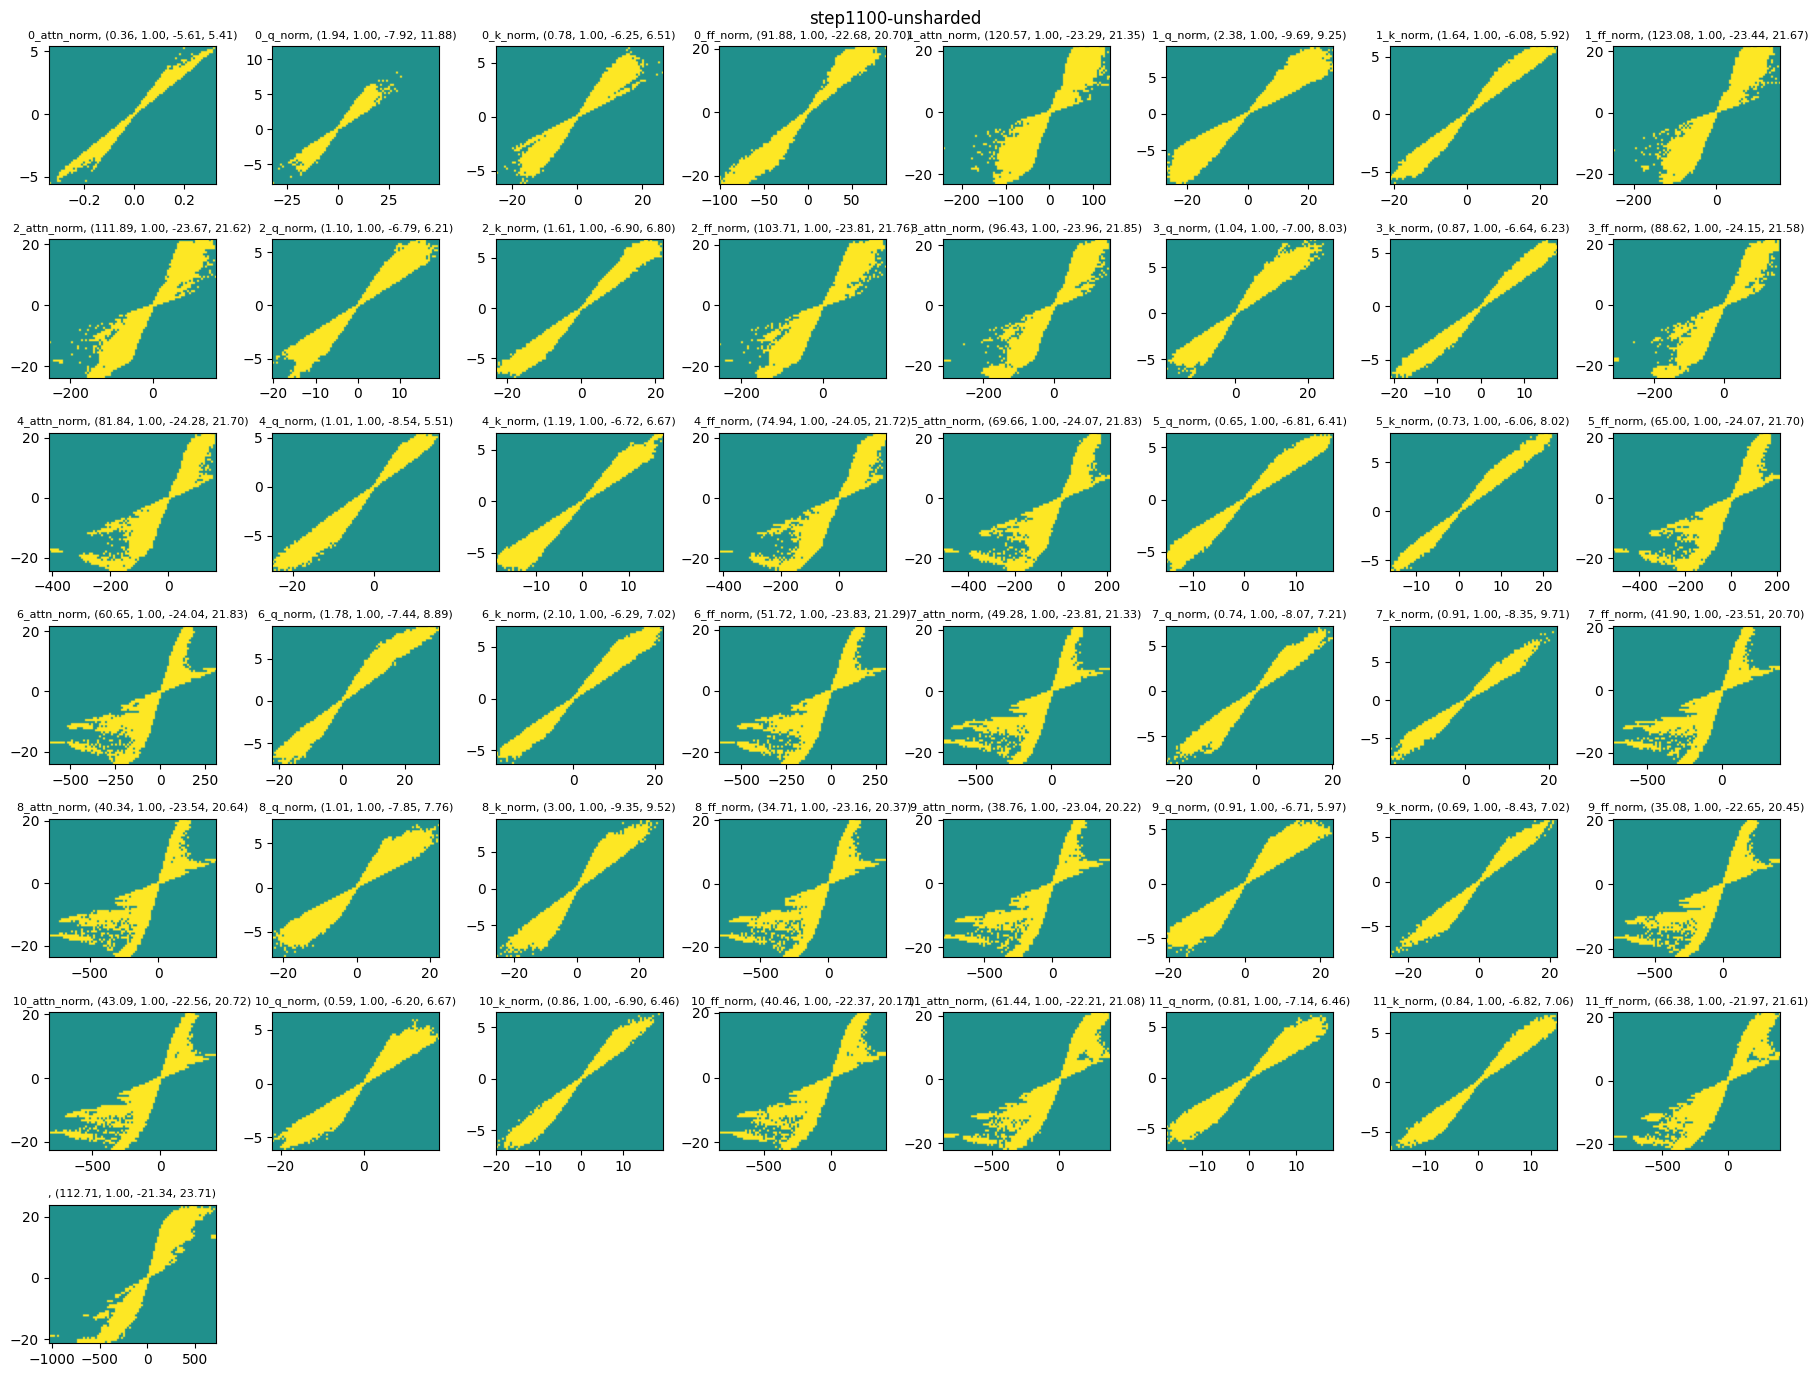

step3100-unsharded


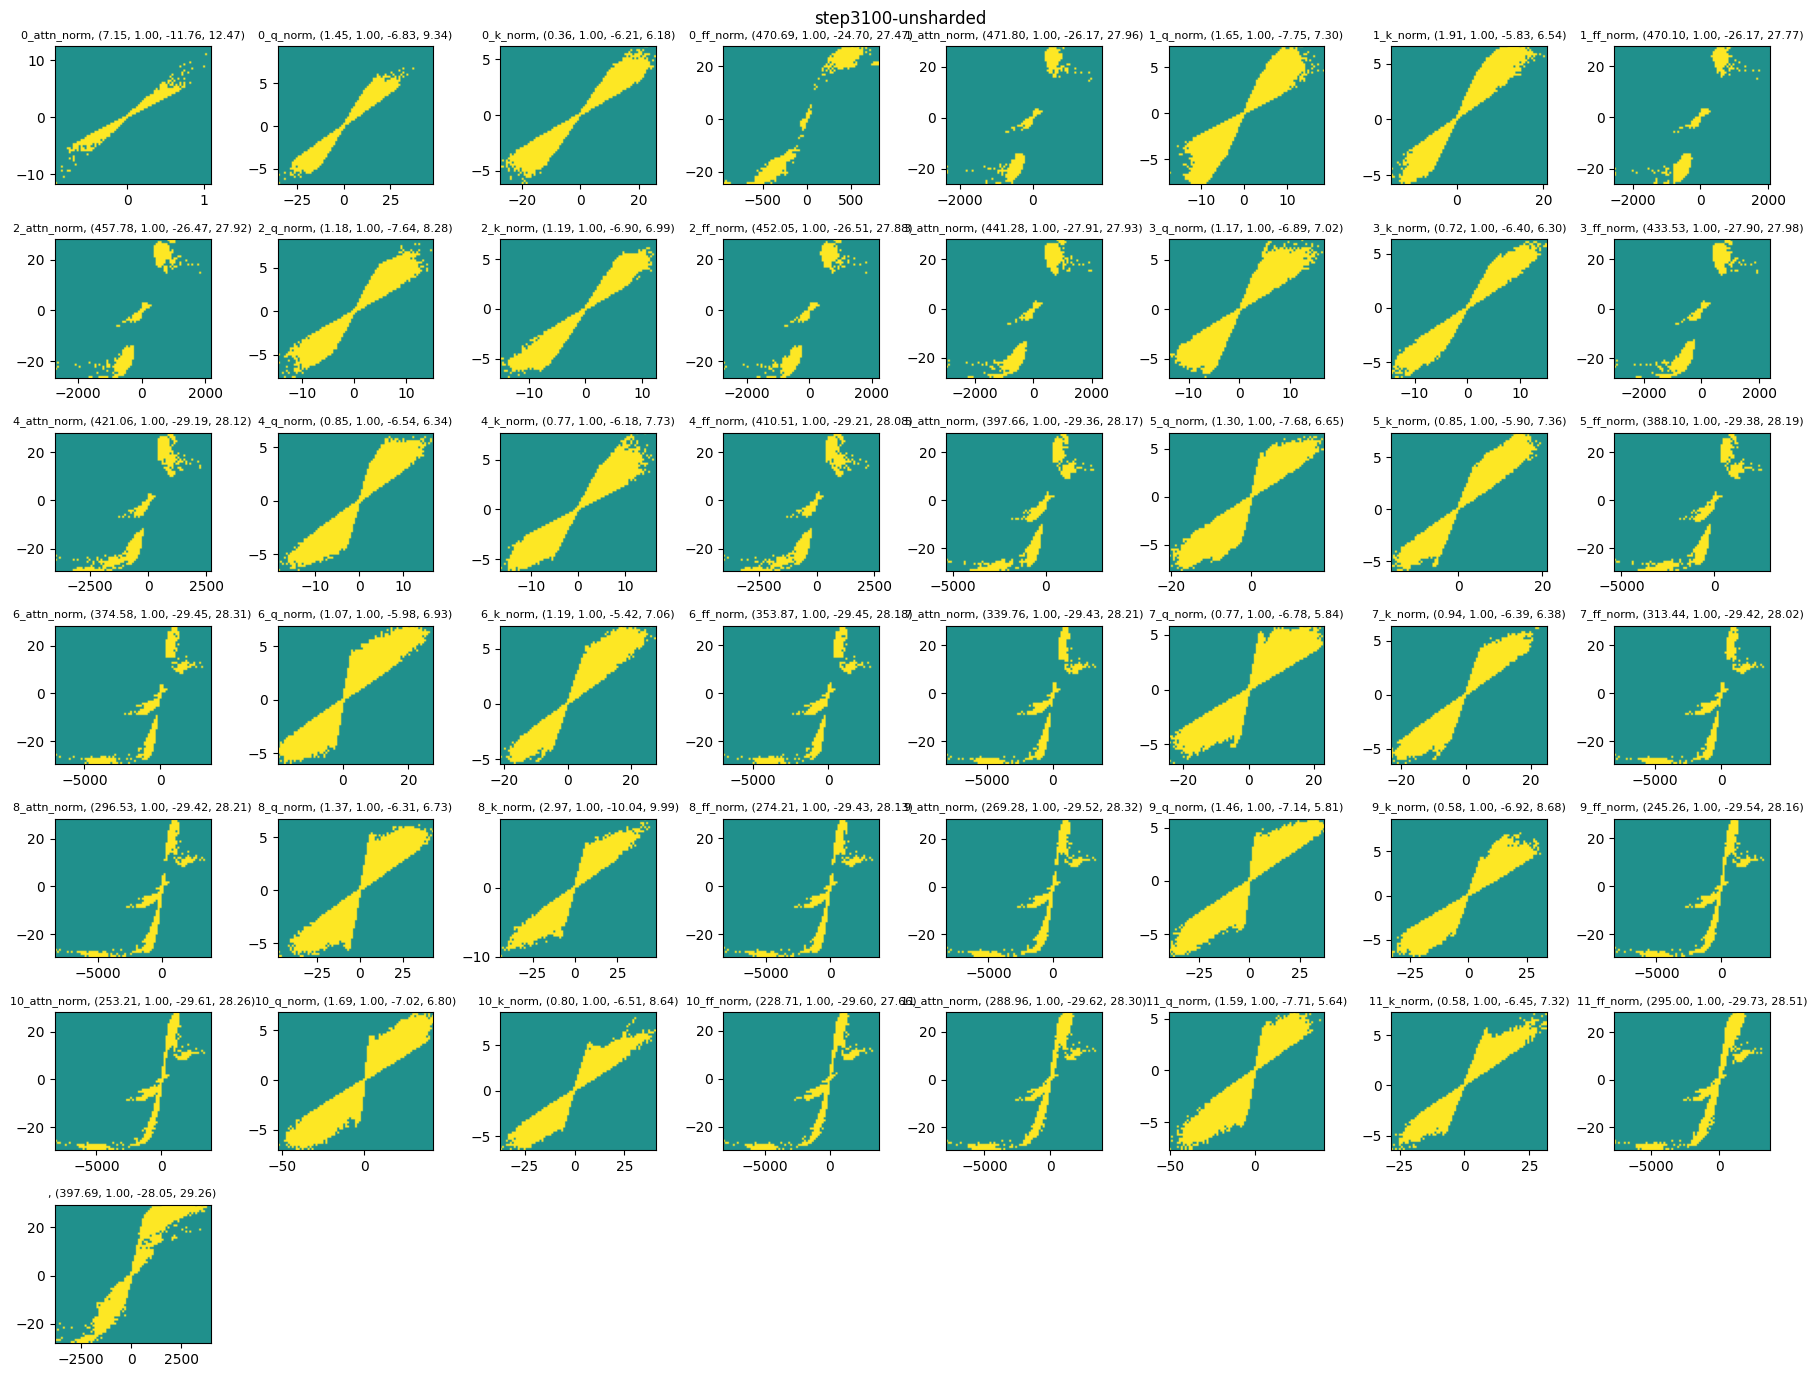

step8400-unsharded


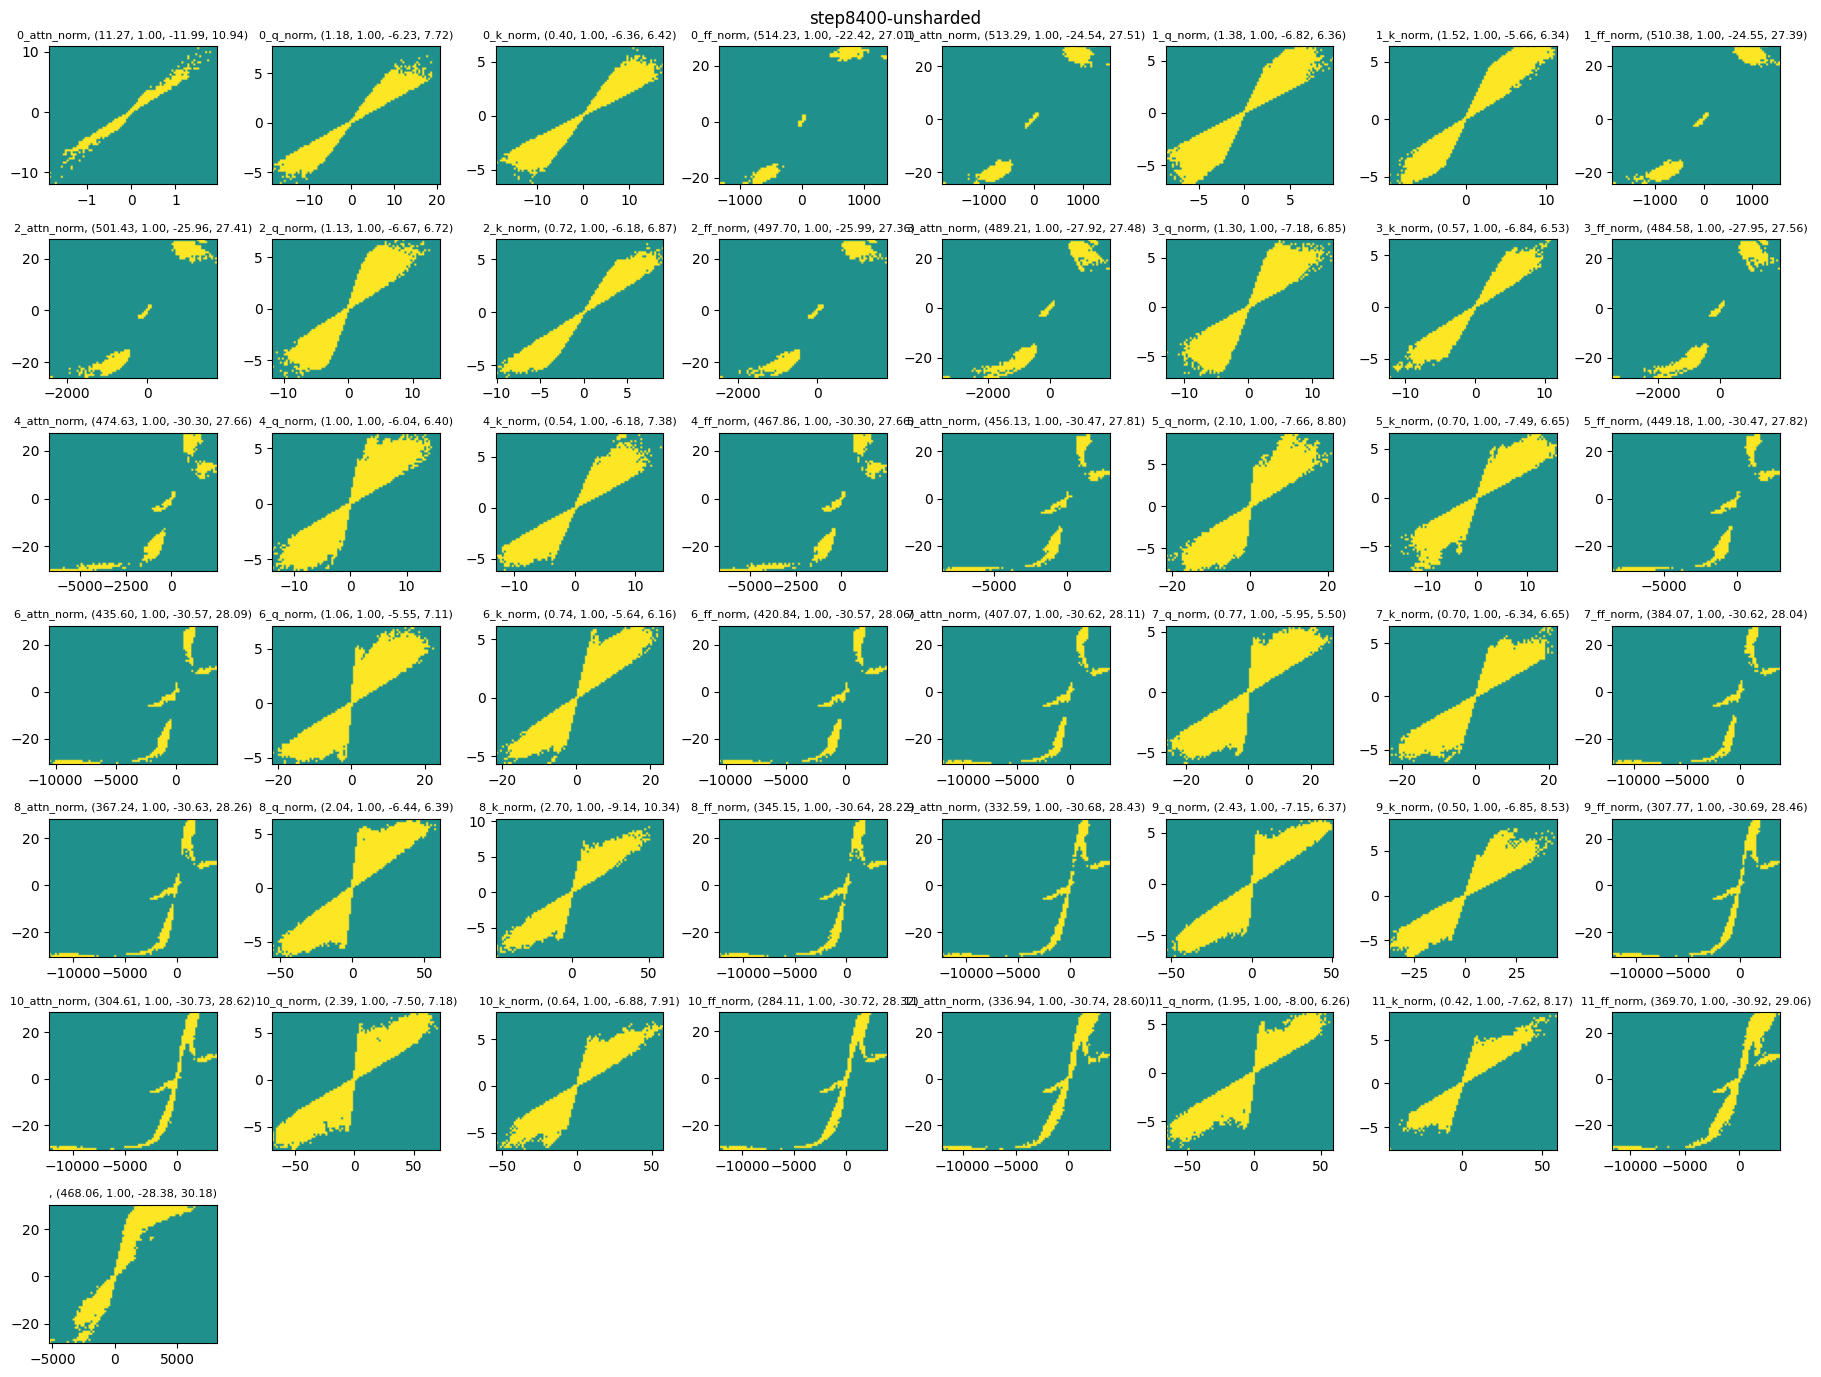

In [17]:
# for step in steps_saved:
#     print(step)
#     ckpt_path = f"{exp_path}/{step}/"
#     config_path = f"{ckpt_path}/config.yaml"
#     weights_path = f"{ckpt_path}/model.pt"
    
#     cfg = TrainConfig.load(config_path)
#     cfg.data.num_workers = 1
#     olmo_model = OLMo(cfg.model)

#     olmo_model.load_state_dict(torch.load(weights_path, weights_only=True), assign=True)
#     olmo_model = olmo_model.to('cuda:0')

#     if batch is None: # just get once
#         train_loader = build_train_dataloader(cfg)
#         iterator = iter(train_loader)
#         batch = next(iterator)
#         input_ids = batch['input_ids'].to('cuda:0')

#     rec = LNDenominatorRecorder(olmo_model, 'rms') 
#     with torch.no_grad():
#         olmo_model(input_ids)
#         rec.next_step()
#     rec.close()
#     del olmo_model

    
#     fig, axes = plt.subplots(7, 8, figsize=(18,14))
#     keys = list(rec.cache.keys())
#     for idx, ax in enumerate(axes.flat):
#         if idx == len(keys):
#             break
#         key = keys[idx]
#         data = rec.cache[key].flatten().numpy()
#         ax.hist(data, bins=200, density=True, alpha=0.6)
#         plot_title = '_'.join(key.split('.')[1:])
#         ax.set_title(plot_title, fontsize=8)
#         ax.set_yscale('log')
#         ax.set_xscale('log')
#     fig.suptitle(step)
#     fig.tight_layout()
#     # fig.savefig(f"{job_path}/{step}.png")
#     plt.close()

#     break
import numpy as np
def kurtosis_numpy(x):
    x = np.asarray(x)
    mean = np.mean(x)
    std = np.std(x, ddof=0)
    n = len(x)
    return np.sum(((x - mean)/std)**4) / n - 3   # Fisher’s definition

for step in steps_saved[::10]:
    print(step)
    ckpt_path = f"{exp_path}/{step}/"
    config_path = f"{ckpt_path}/config.yaml"
    weights_path = f"{ckpt_path}/model.pt"
    
    cfg = TrainConfig.load(config_path)
    cfg.data.paths = ["/n/holylfs06/LABS/kempner_shared/Everyone/testbed/text/dolma/tokenized/t5-base/c4/" + x.split('/')[-1] for x in cfg.data.paths]
    
    cfg.data.num_workers = 1
    olmo_model = OLMo(cfg.model)

    olmo_model.load_state_dict(torch.load(weights_path, weights_only=True), assign=True)
    olmo_model = olmo_model.to('cuda:0')

    if batch is None: # just get once
        cfg.global_train_batch_size = 1
        
        train_loader = build_train_dataloader(cfg)
        iterator = iter(train_loader)
        batch = next(iterator)
        input_ids = batch['input_ids'].to('cuda:0')

    rec = LNDenominatorRecorder(olmo_model, 'rms') 
    with torch.no_grad():
        olmo_model(input_ids)
        rec.next_step()
    rec.close()
    del olmo_model

    
    fig = plt.figure(figsize=(18,14))
    keys = list(rec.cache.keys())
    for idx in range(len(keys)):
        ax = fig.add_subplot(7, 8, 1+idx, projection='scatter_density')
        
        key = keys[idx]
        inputs = rec.cache[key][0].flatten().numpy()
        outputs = rec.cache[key][1].flatten().numpy()

        ax.scatter_density(x=inputs,y=outputs, dpi=50, vmin=-1, vmax=1)
        
        plot_title = '_'.join(key.split('.')[2:])
        plot_title = f"{plot_title}, ({kurtosis_numpy(outputs):.2f}, {outputs.var():.2f}, {outputs.min():.2f}, {outputs.max():.2f})"
        ax.set_title(plot_title, fontsize=8)
    fig.suptitle(step)
    fig.tight_layout()
    # fig.savefig(f"{job_path}/scatter_plot_{step}.png")
    # print(f"{job_path}/scatter_plot_{step}.png")
    plt.show()
    plt.close()

In [4]:
olmo_model = OLMo(cfg.model)

olmo_model.load_state_dict(torch.load(weights_path, weights_only=True), assign=True, strict=False)

<All keys matched successfully>

In [5]:
olmo_model.transformer.blocks[5].k_norm.weight

Parameter containing:
tensor([0.9302, 1.2060, 1.0844,  ..., 1.2734, 1.3452, 1.2830], device='cuda:0',
       requires_grad=True)